Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Вспомогательная функция для отрисовки графиков
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.show()

### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

In [ ]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [ ]:
# Flatten изображений
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# Масштабирование
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
# One-Hot Encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [ ]:
# Проверка размеров
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 3072)
(10000, 3072)
(50000, 10)
(10000, 10)


### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2465 - loss: 2.0355 - val_accuracy: 0.2951 - val_loss: 1.9325
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3216 - loss: 1.8877 - val_accuracy: 0.3115 - val_loss: 1.9297
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3424 - loss: 1.8376 - val_accuracy: 0.3524 - val_loss: 1.8420
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3518 - loss: 1.8112 - val_accuracy: 0.3401 - val_loss: 1.8419
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3524 - loss: 1.8069 - val_accuracy: 0.3517 - val_loss: 1.8150
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3620 - loss: 1.7898 - val_accuracy: 0.3541 - val_loss: 1.8212
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3616 - loss: 1.7839 - val_accuracy: 0.3664 - val_loss: 1.7973
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3670 - loss: 1.7736 - val_accuracy: 0.

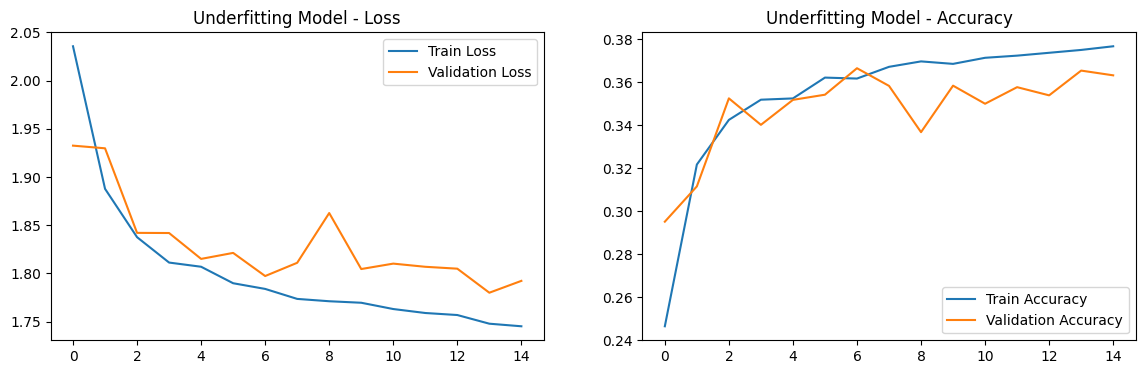

In [ ]:
# Модель с недообучением
model_underfit = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Компиляция
model_underfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_underfit = model_underfit.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2
)

# Графики
plot_history(history_underfit, "Underfitting Model")

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.2994 - loss: 1.9503 - val_accuracy: 0.3499 - val_loss: 1.7970
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.3827 - loss: 1.7106 - val_accuracy: 0.3910 - val_loss: 1.7042
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.4207 - loss: 1.6118 - val_accuracy: 0.4164 - val_loss: 1.6324
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.4436 - loss: 1.5538 - val_accuracy: 0.4522 - val_loss: 1.5631
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.4609 - loss: 1.5037 - val_accuracy: 0.4428 - val_loss: 1.5669
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.4767 - loss: 1.4669 - val_accuracy: 0.4708 - val_loss: 1.4989
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.4894 - loss: 1.4284 - val_accuracy: 0.4663 - val_loss: 1.5091
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.4998 - loss: 1.4005 - 

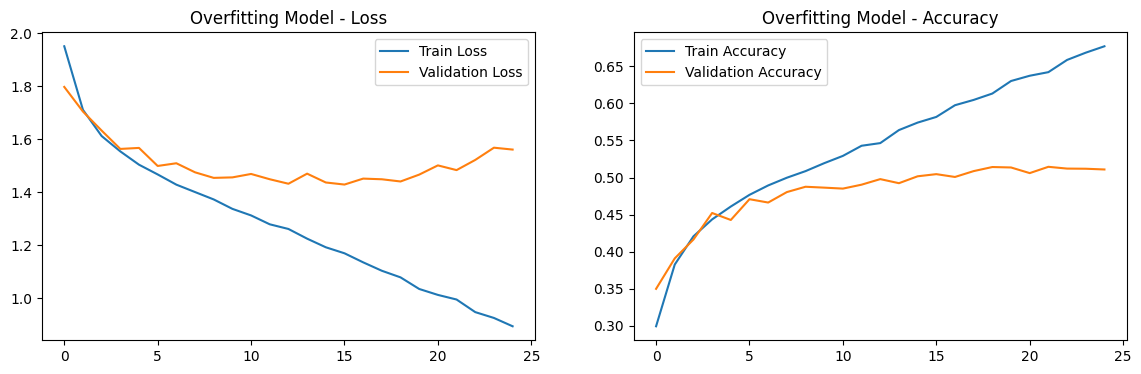

In [ ]:
# Модель с переобучением
model_overfit = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Компиляция
model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_overfit = model_overfit.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

# Графики
plot_history(history_overfit, "Overfitting Model")

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

Epoch 1/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.1838 - loss: 2.5062
Epoch 1: val_accuracy improved from None to 0.32550, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 247ms/step - accuracy: 0.2410 - loss: 2.1858 - val_accuracy: 0.3255 - val_loss: 1.9317 - learning_rate: 0.0010
Epoch 2/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.3158 - loss: 1.9482
Epoch 2: val_accuracy improved from 0.32550 to 0.35480, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - accuracy: 0.3169 - loss: 1.9379 - val_accuracy: 0.3548 - val_loss: 1.8394 - learning_rate: 0.0010
Epoch 3/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.3255 - loss: 1.8934
Epoch 3: val_accuracy improved from 0.35480 to 0.36450, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_

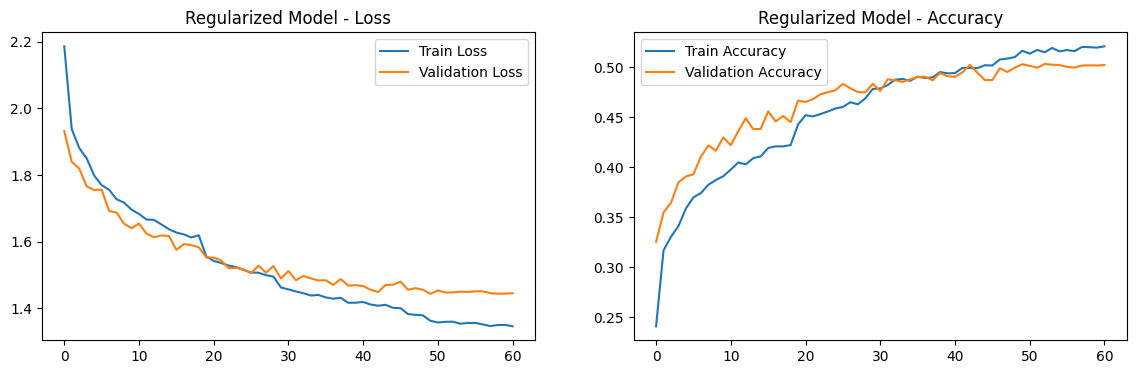

In [ ]:
from tensorflow.keras import regularizers

model_regularized = keras.Sequential([

    layers.Input(shape=(3072,)),
    layers.Dense(2048, activation='relu',kernel_regularizer=regularizers.l2(1e-5)),
    layers.Dropout(0.3),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model_regularized.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=False
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_cifar10_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_regularized = model_regularized.fit(
    X_train,
    y_train,
    epochs=70,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

plot_history(history_regularized, "Regularized Model")

### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

In [ ]:
# загрузка лучшей модели
best_model = keras.models.load_model("best_cifar10_model.keras")

# предсказания
y_pred_probs = best_model.predict(X_test)

# перевод вероятностей в классы
y_pred = np.argmax(y_pred_probs, axis=1)

# перевод one-hot обратно в метки
y_true = np.argmax(y_test, axis=1)

# вычисление accuracy
test_accuracy = accuracy_score(y_true, y_pred)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Test accuracy: 0.5035


# Вывод

По моему мнению, наибольшее влияние на итоговый результат оказали слои Dropout. Они снижают переобучение, случайно отключая часть нейронов, что заставляет модель учить более устойчивые и обобщающие признаки.

Также важную роль сыграли callback-функции, которые позволили остановить обучение до начала сильного переобучения и улучшить сходимость